# Explainable AI - SHAP classification

This notebook is practice of SHAP library usage on classification problem solution for <a href="https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-4">Bank Customer Churn</a> dataset.


## Imports & Files downloads

In [1]:
%load_ext autoreload
%autoreload 2

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import pandas as pd
import numpy as np

from mlpeople.io.google_drive import download_file_iss

# download files from google drive
download_file_iss('1Xz-cqp6y-Y_oCiaSJeNsbU3-o5lM-5wY', output_path='./downloads/train.csv')
download_file_iss('1jsg2iPVphDMiHCEyqQeDSc4yDcMB3-r_', output_path='./downloads/test.csv')
download_file_iss('1tv0beG2n8cUQ6KcdaXhFzQI_Fd9640gg', output_path='./downloads/sample_submission.csv')

# read train.csv / show first 5 rows / show info
raw_df = pd.read_csv('downloads/train.csv', index_col=0)
target_col = "Exited"
raw_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


## Logistic Regression - All Features (Poly 1 degree)

In [ ]:
# use previously implemented run_experiment_poly method to preprocess data and train model
from mlpeople.optimization.experiments.polynomial_pipeline_experiments import run_experiment_poly

result_lr_1 = run_experiment_poly(
    raw_df,
    target_col,
    stratify_col=target_col,
    drop_cols=["Surname", "CustomerId"],
    scale_mode="standard",
    encode_drop=None,
    polynomial_degree=1,
    model=LogisticRegression(solver='liblinear'),
)

lg_roc_auc_train = result_lr_1["roc_auc_train"]
lg_roc_auc_val = result_lr_1["roc_auc_val"]
lg_1_model_pipeline = result_lr_1["pipeline"]

lg_roc_auc_train, lg_roc_auc_val

(0.8825370482620953, 0.8796604705398174)

In [46]:
# Extract model
model_lr = lg_1_model_pipeline.named_steps['classifier']
model_lr

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# Extract transformed X
feature_names_lr_1 = lg_1_model_pipeline[-2].get_feature_names_out()
X_transformed_lr_1 = lg_1_model_pipeline[:-1].transform(raw_df)
X_transformed_df_lr_1 = pd.DataFrame(X_transformed_lr_1, columns=feature_names_lr_1)
X_transformed_df_lr_1.head()

,num__CreditScore,num__Age,num__Tenure,num__Balance,num__NumOfProducts,num__HasCrCard,num__IsActiveMember,num__EstimatedSalary,cat__Geography_France,cat__Geography_Germany,cat__Geography_Spain,cat__Gender_Female,cat__Gender_Male
0,0.264887,-1.067561,-0.368848,-0.717950,2.646802,0.515062,-0.983306,1.373926,1.0,0.0,0.0,0.0,1.0
1,0.389313,-0.453167,-1.447264,-0.717950,0.769304,-1.941514,1.016977,-1.190154,1.0,0.0,0.0,1.0,0.0
2,0.320187,1.758651,0.350096,-0.717950,2.646802,-1.941514,-0.983306,1.352637,1.0,0.0,0.0,1.0,0.0
3,1.301774,0.775621,0.350096,0.673394,0.769304,0.515062,-0.983306,0.952344,0.0,1.0,0.0,0.0,1.0
4,-1.587685,2.127288,-1.806736,1.080717,-1.108193,0.515062,-0.983306,1.285185,0.0,1.0,0.0,1.0,0.0


### SHAP Global plots - Logistic Regression poly 1

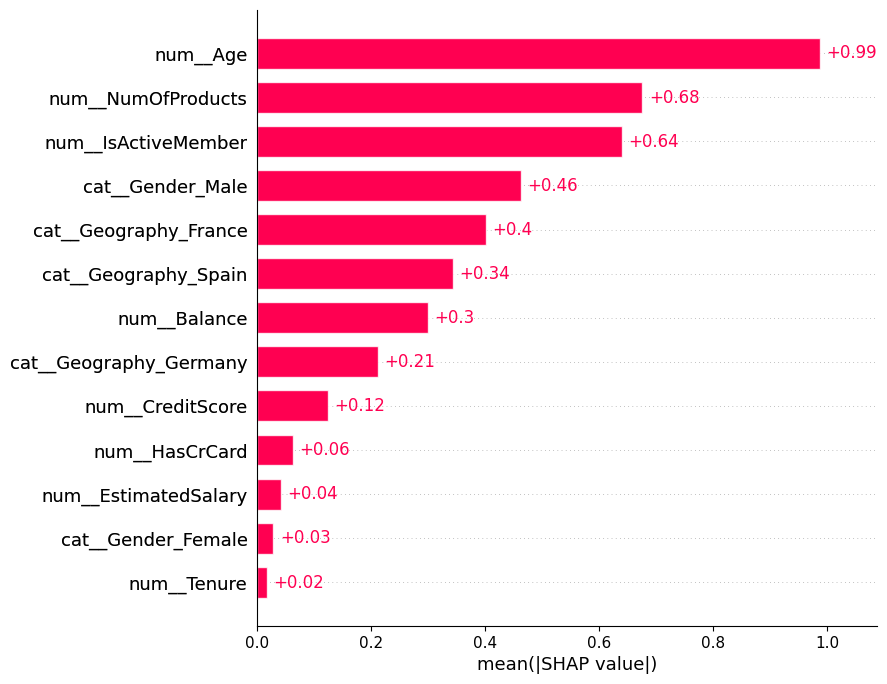

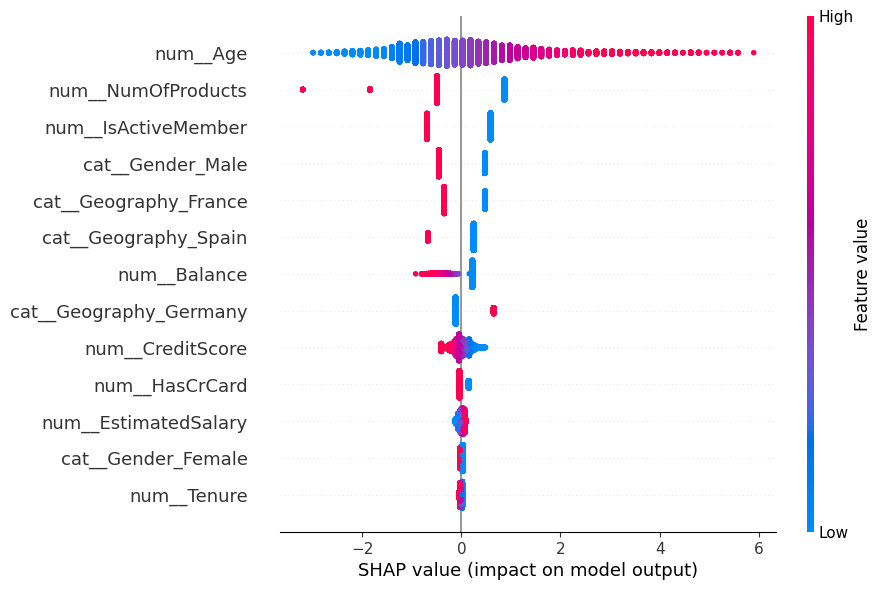

In [ ]:
import shap

# Create SHAP explainer
explainer_lr = shap.LinearExplainer(model_lr, X_transformed_df_lr_1)
shap_values_lr = explainer_lr(X_transformed_df_lr_1)

# Global plots
shap.plots.bar(shap_values_lr, max_display=None)
shap.plots.beeswarm(shap_values_lr, max_display=None)

### SHAP Single prediction samples - Logistic Regression poly 1

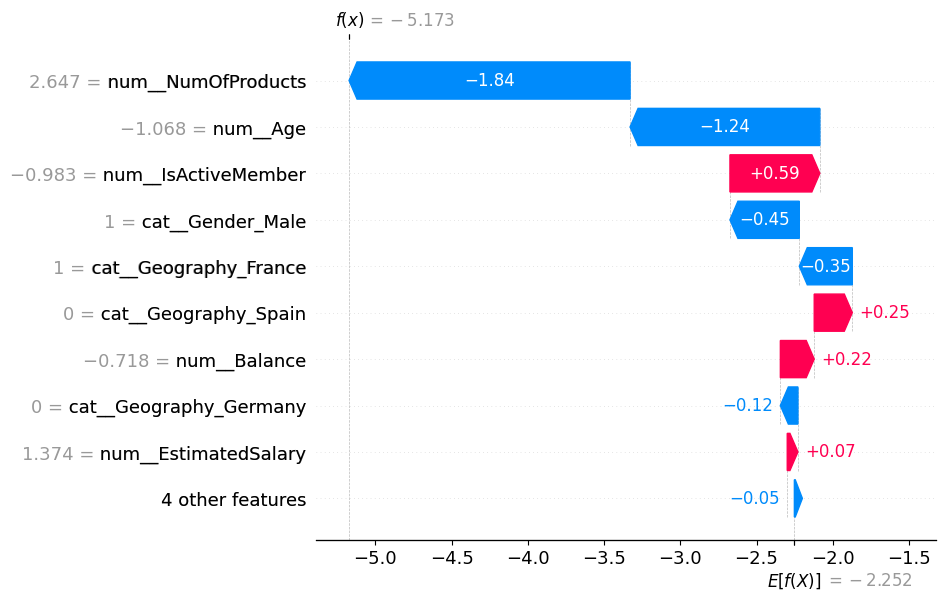

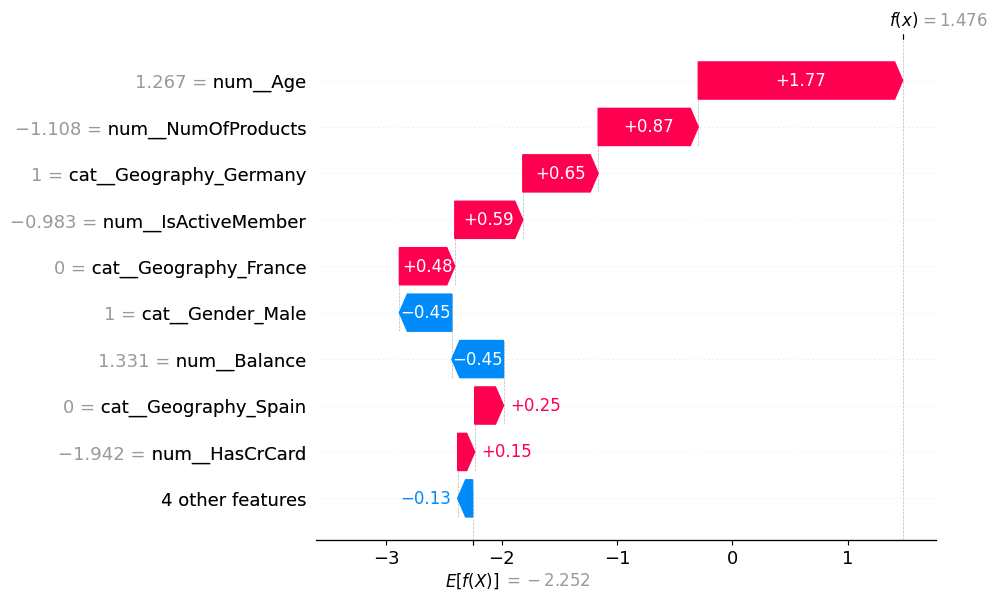

In [51]:
# Single predictions
shap.plots.waterfall(shap_values_lr[0])
shap.plots.waterfall(shap_values_lr[100])

### SHAP Dependence plots - Logistic Regression poly 1

In [ ]:
X_transformed_df_lr_1.columns

Index(['num__CreditScore', 'num__Age', 'num__Tenure', 'num__Balance',
       'num__NumOfProducts', 'num__HasCrCard', 'num__IsActiveMember',
       'num__EstimatedSalary', 'cat__Geography_France',
       'cat__Geography_Germany', 'cat__Geography_Spain', 'cat__Gender_Female',
       'cat__Gender_Male'],
      dtype='object')

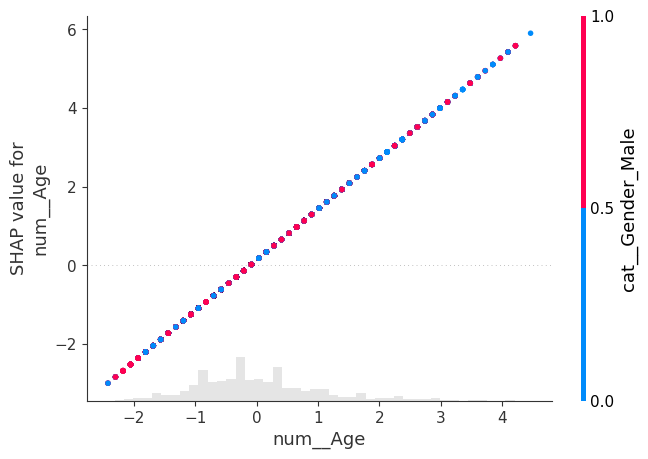

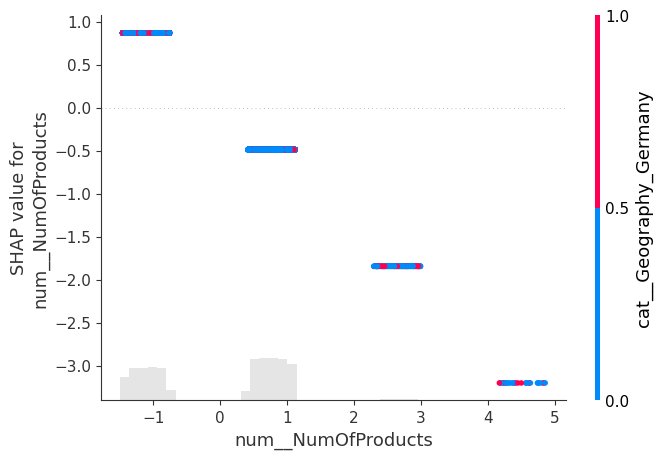

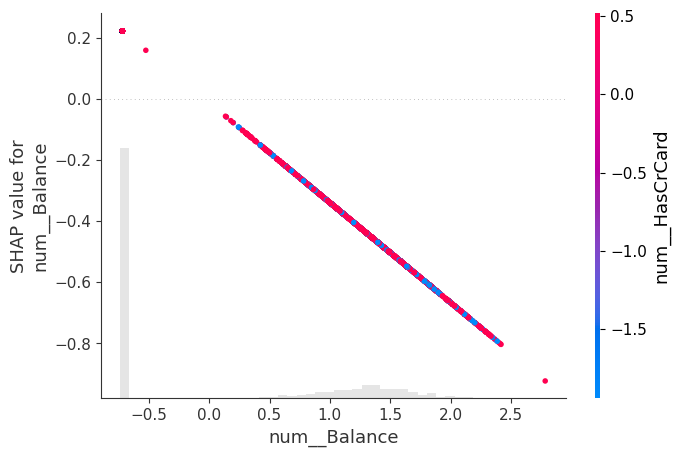

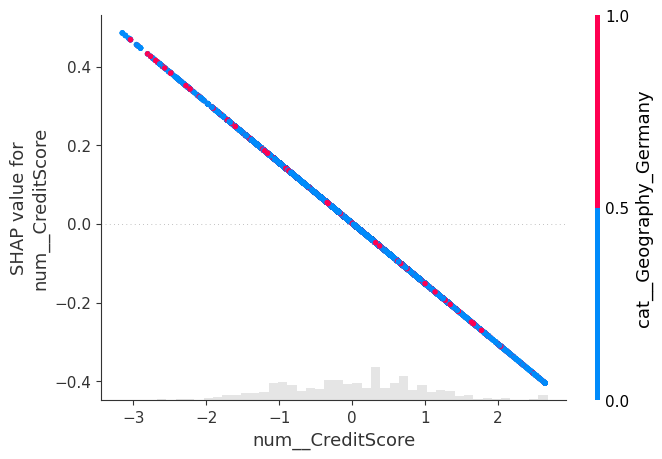

In [73]:
shap.plots.scatter(shap_values_lr[:, "num__Age"], color=shap_values_lr[:, "cat__Gender_Male"])
shap.plots.scatter(shap_values_lr[:, "num__NumOfProducts"], color=shap_values_lr[:, "cat__Geography_Germany"])
shap.plots.scatter(shap_values_lr[:, "num__Balance"], color=shap_values_lr)
shap.plots.scatter(shap_values_lr[:, "num__CreditScore"], color=shap_values_lr)

### SHAP Heatmap - Logistic Regression poly 1

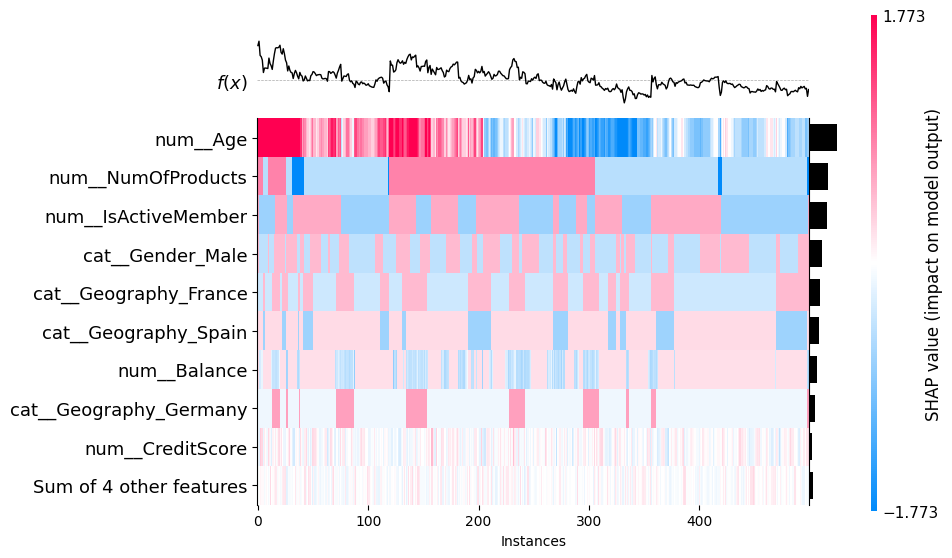

In [149]:
shap.plots.heatmap(shap_values_lr[:500]);

## Logistic Regression - Custom Features (Poly 3 degree)

In [ ]:
from math import inf

binary_cat_flag_col_is_germany = {
  'flag_name': 'IsGermany',
    'value': 'Germany',
    'drop_original': True
}

binary_cat_flag_cols_fixed = {
    'Geography': [binary_cat_flag_col_is_germany]
}

num_bin_cols_fixed = {
    "EstimatedSalary": {
        "bins": [0, 25000, 100000, inf],
        "labels": ["low", "medium", "high"],
        "new_col": "SalaryScore",
        "drop_original": True
    },
    "CreditScore": {
        "bins": [0, 675, inf],
        "labels": ["low", "high"],
        "new_col": "CreditScoreScore",
        "drop_original": True
    }
}

result_lr_3 = run_experiment_poly(
    raw_df,
    target_col,
    stratify_col=target_col,
    drop_cols=["Surname", "CustomerId"],
    scale_mode="standard",
    encode_drop=None,
    polynomial_degree=3,
    binary_cat_flag_cols=binary_cat_flag_cols_fixed,
    model=LogisticRegression(solver='liblinear'),
    num_bin_cols=num_bin_cols_fixed
)

lg_roc_auc_train = result_lr_3["roc_auc_train"]
lg_roc_auc_val = result_lr_3["roc_auc_val"]
lg_3_model_pipeline = result_lr_3["pipeline"]

lg_roc_auc_train, lg_roc_auc_val

(0.9389320196758991, 0.93874134028397)

In [75]:
# Extract model
model_lr_3 = lg_3_model_pipeline.named_steps['classifier']
model_lr_3

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# Extract transformed X
feature_names_lr_3 = lg_3_model_pipeline[-2].get_feature_names_out()
X_transformed_lr_3 = lg_3_model_pipeline[:-1].transform(raw_df)
X_transformed_df_lr_3 = pd.DataFrame(X_transformed_lr_3, columns=feature_names_lr_3)
X_transformed_df_lr_3.head()

,num__Age,num__Tenure,num__Balance,num__NumOfProducts,num__HasCrCard,num__IsActiveMember,num__IsGermany,num__Age^2,num__Age Tenure,num__Age Balance,...,num__IsActiveMember^2 IsGermany,num__IsActiveMember IsGermany^2,num__IsGermany^3,cat__Gender_Female,cat__Gender_Male,cat__SalaryScore_high,cat__SalaryScore_low,cat__SalaryScore_medium,cat__CreditScoreScore_high,cat__CreditScoreScore_low
0,-1.067561,-0.368848,-0.717950,2.646802,0.515062,-0.983306,-0.467331,1.139686,0.393768,0.766455,...,-0.451858,-0.214752,-0.102064,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,-0.453167,-1.447264,-0.717950,0.769304,-1.941514,1.016977,-0.467331,0.205360,0.655852,0.325351,...,-0.483333,0.222106,-0.102064,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,1.758651,0.350096,-0.717950,2.646802,-1.941514,-0.983306,-0.467331,3.092855,0.615696,-1.262624,...,-0.451858,-0.214752,-0.102064,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.775621,0.350096,0.673394,0.769304,0.515062,-0.983306,2.139813,0.601588,0.271542,0.522299,...,2.068965,-4.502362,9.797778,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,2.127288,-1.806736,1.080717,-1.108193,0.515062,-0.983306,2.139813,4.525354,-3.843447,2.298996,...,2.068965,-4.502362,9.797778,1.0,0.0,1.0,0.0,0.0,0.0,1.0


### SHAP Global plots - Logistic Regression poly 3

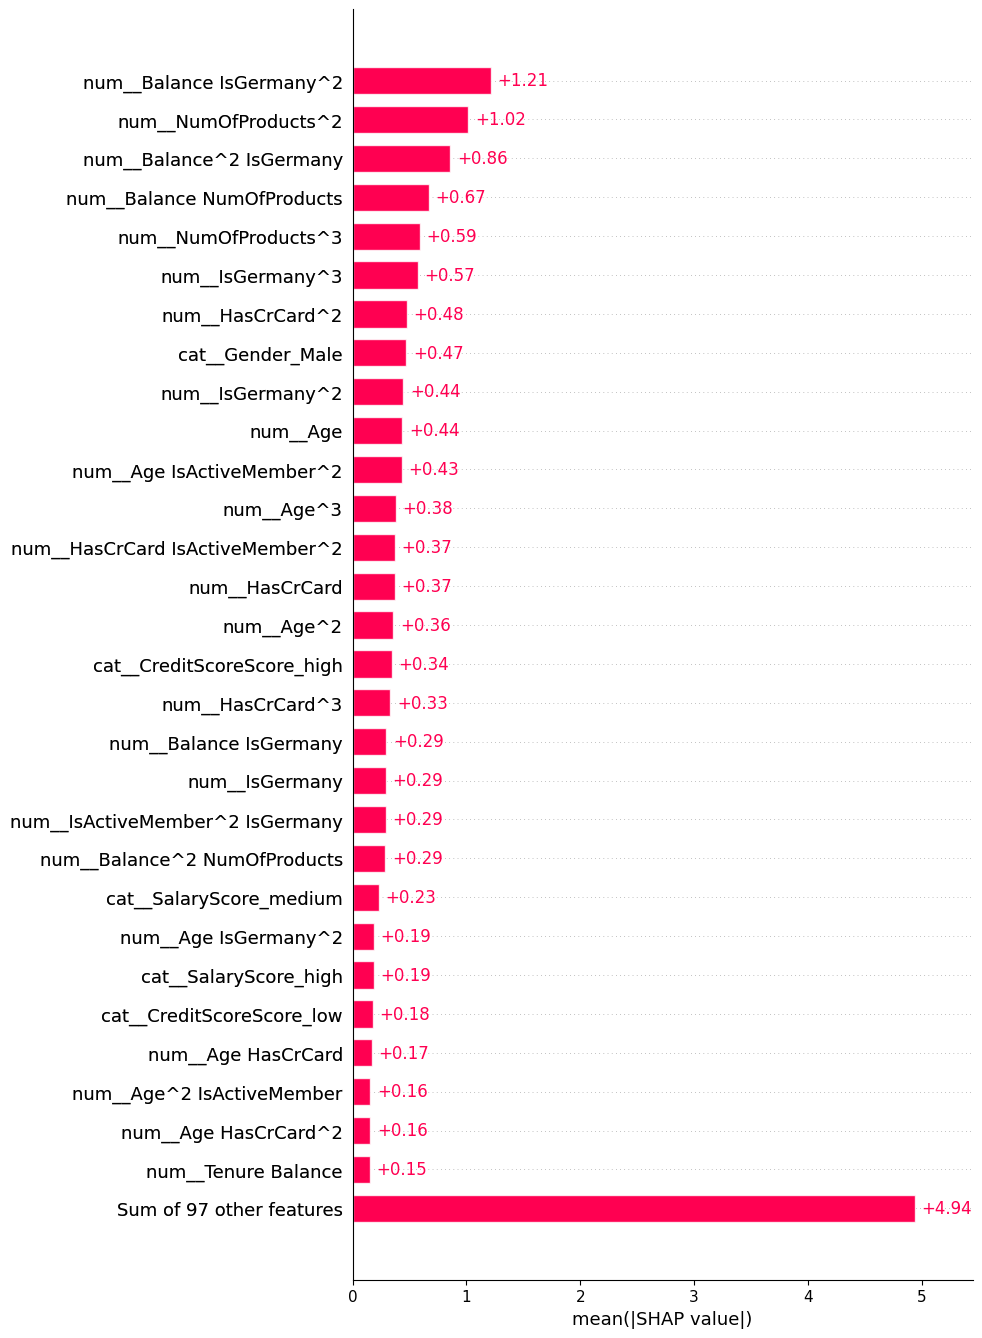

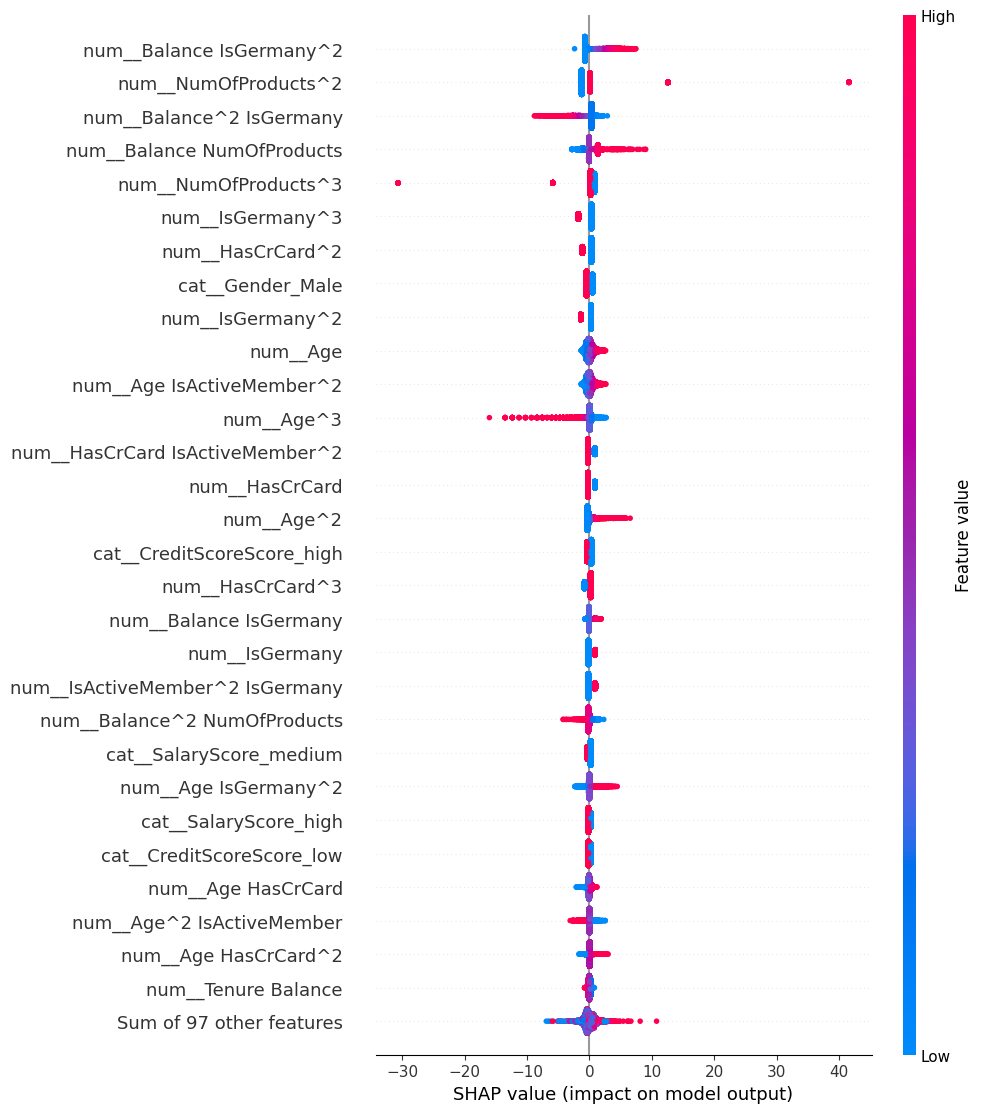

In [ ]:
import shap

# Create SHAP explainer
explainer_lr_3 = shap.LinearExplainer(model_lr_3, X_transformed_df_lr_3)
shap_values_lr_3 = explainer_lr_3(X_transformed_df_lr_3)

# Global plots
shap.plots.bar(shap_values_lr_3, max_display=30)
shap.plots.beeswarm(shap_values_lr_3, max_display=30)

 - In reality features like isGermany^2 isGermany^3 have no sense since it is categorical encoded flag. But as seen from above a lot of important features contain them. Also previously for the same dataset it was explore that in case we do not scale binary columns values auroc score is worse. For some reason it gives improvements to model prediction.

### SHAP Single prediction samples - Logistic Regression poly 3

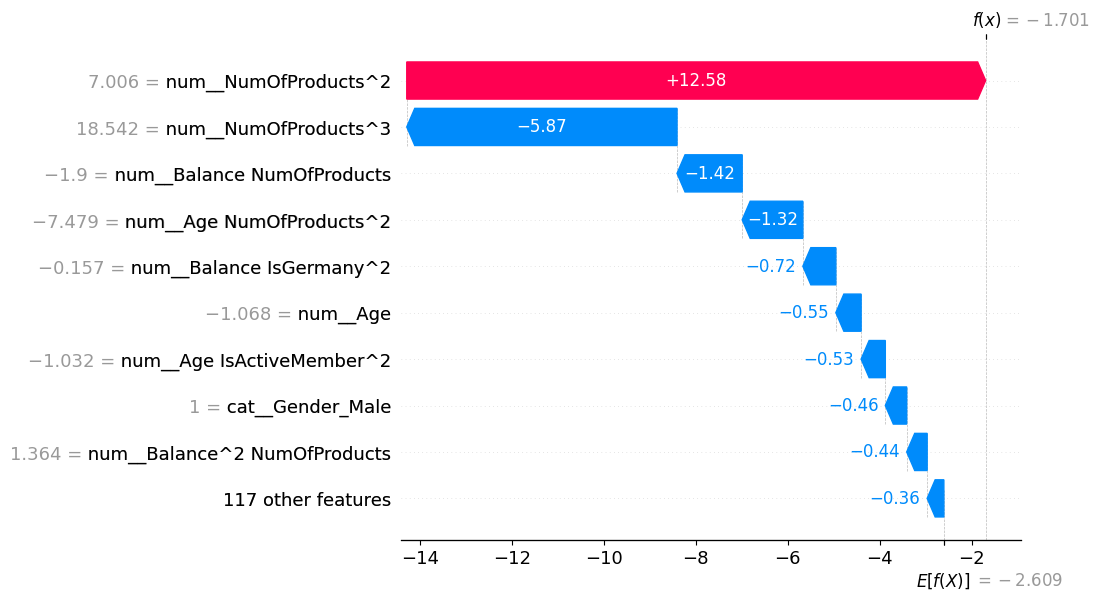

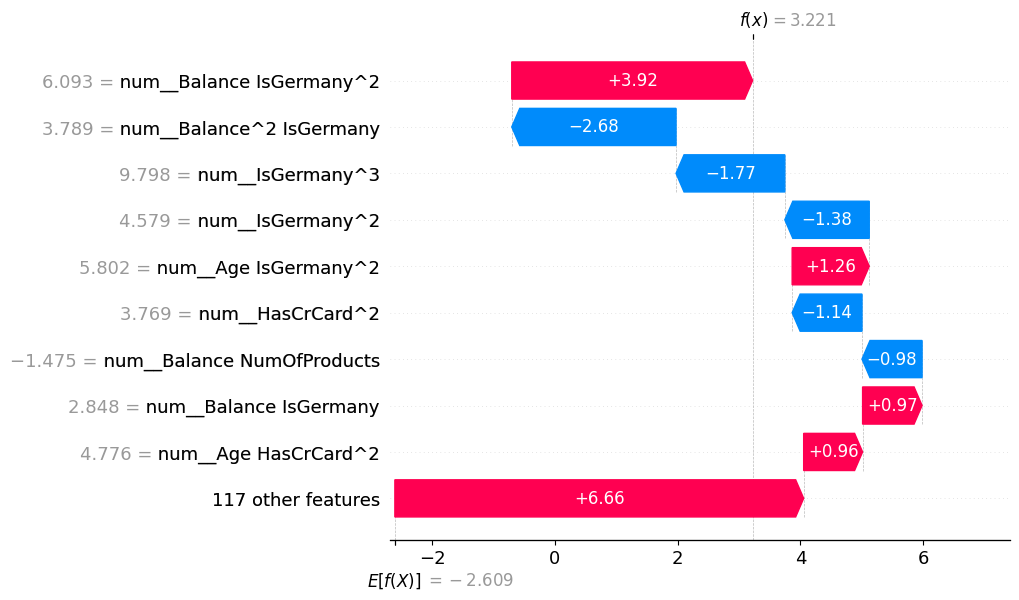

In [81]:
# Single predictions
shap.plots.waterfall(shap_values_lr_3[0])
shap.plots.waterfall(shap_values_lr_3[100])

## Decision Tree

In [117]:
result_dt = run_experiment_poly(
    raw_df,
    target_col,
    stratify_col=target_col,
    drop_cols=["Surname", "CustomerId"],
    scale_mode="standard",
    encode_drop=None,
    polynomial_degree=1,
    model=DecisionTreeClassifier(max_depth=8, max_leaf_nodes=40, random_state=42),
)

lg_roc_auc_train = result_dt["roc_auc_train"]
lg_roc_auc_val = result_dt["roc_auc_val"]
dt_model_pipeline = result_dt["pipeline"]

lg_roc_auc_train, lg_roc_auc_val

(0.9288947824729369, 0.9240688661773784)

In [118]:
# Extract model
model_dt = dt_model_pipeline.named_steps['classifier']
model_dt

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",40
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node

In [119]:
# Extract transformed X
feature_names_dt = dt_model_pipeline[-2].get_feature_names_out()
X_transformed_dt = dt_model_pipeline[:-1].transform(raw_df)
X_transformed_df_dt = pd.DataFrame(X_transformed_dt, columns=feature_names_dt)
X_transformed_df_dt.head()

,num__CreditScore,num__Age,num__Tenure,num__Balance,num__NumOfProducts,num__HasCrCard,num__IsActiveMember,num__EstimatedSalary,cat__Geography_France,cat__Geography_Germany,cat__Geography_Spain,cat__Gender_Female,cat__Gender_Male
0,0.264887,-1.067561,-0.368848,-0.717950,2.646802,0.515062,-0.983306,1.373926,1.0,0.0,0.0,0.0,1.0
1,0.389313,-0.453167,-1.447264,-0.717950,0.769304,-1.941514,1.016977,-1.190154,1.0,0.0,0.0,1.0,0.0
2,0.320187,1.758651,0.350096,-0.717950,2.646802,-1.941514,-0.983306,1.352637,1.0,0.0,0.0,1.0,0.0
3,1.301774,0.775621,0.350096,0.673394,0.769304,0.515062,-0.983306,0.952344,0.0,1.0,0.0,0.0,1.0
4,-1.587685,2.127288,-1.806736,1.080717,-1.108193,0.515062,-0.983306,1.285185,0.0,1.0,0.0,1.0,0.0


### SHAP Global plots - Decision Tree

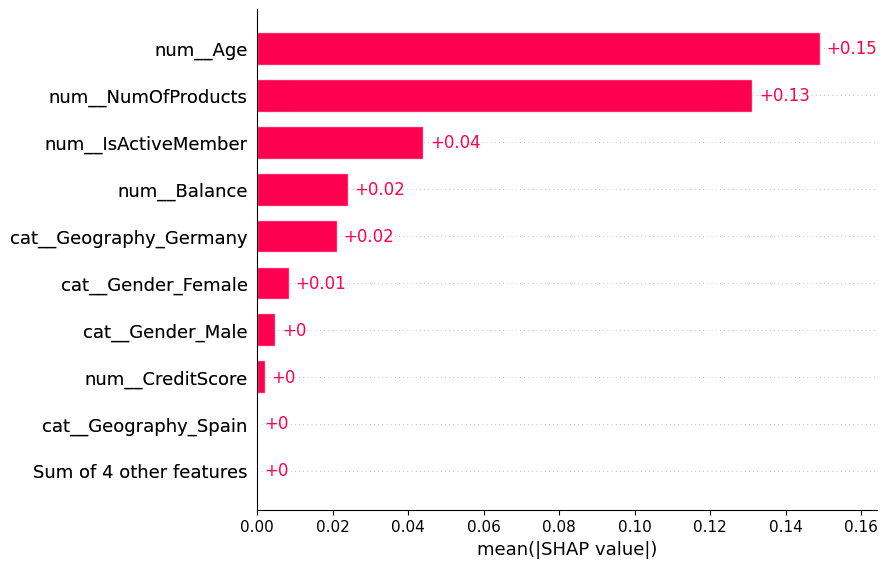

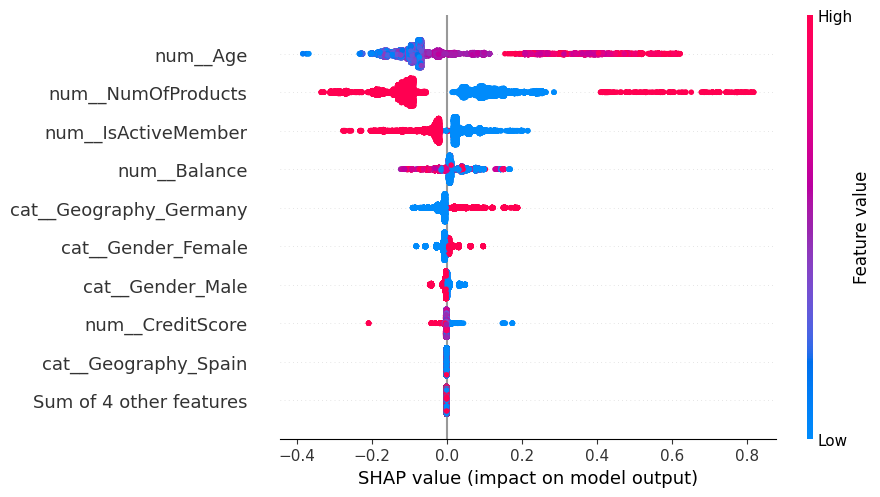

In [125]:
import shap

# Create SHAP explainer
explainer_dt = shap.TreeExplainer(model_dt)

# Calculate SHAP values
shap_values_dt = explainer_dt(X_transformed_df_dt)

# Global plots
shap.plots.bar(shap_values_dt[:, :, 1])
shap.plots.beeswarm(shap_values_dt[:, :, 1])

### SHAP Single prediction samples - Decision Tree

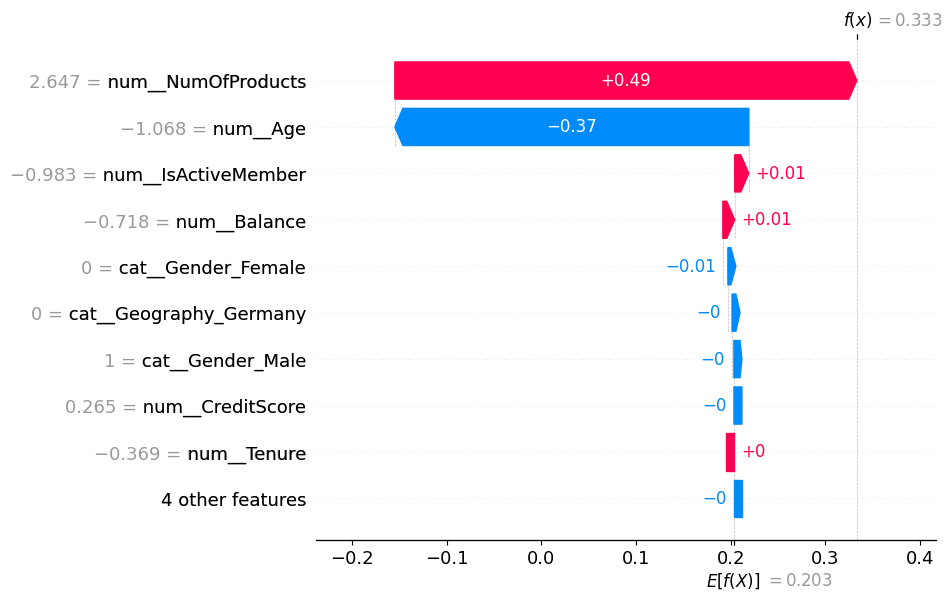

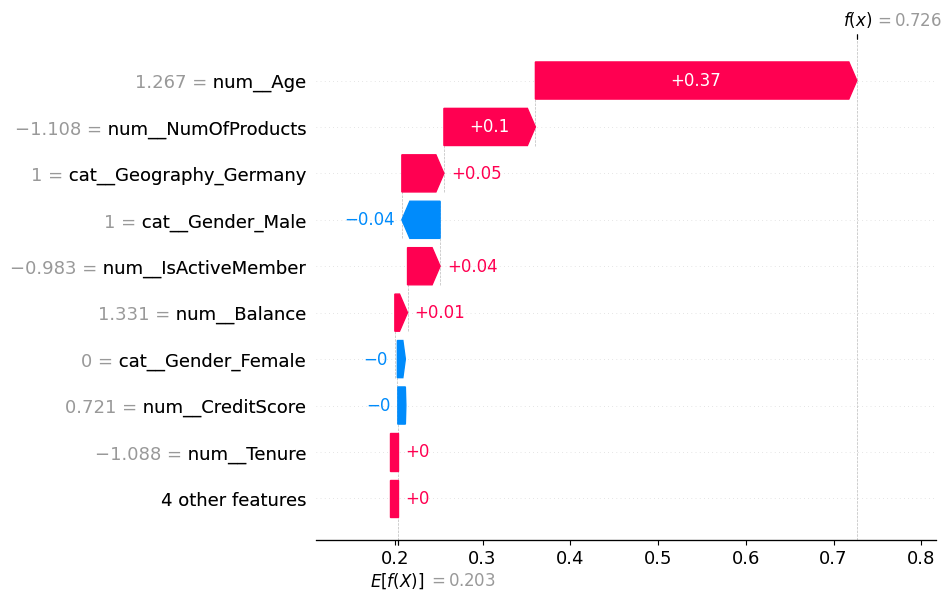

In [130]:
# Single predictions
shap.plots.waterfall(shap_values_dt[0, :, 1])
shap.plots.waterfall(shap_values_dt[100, :, 1])

### SHAP Dependence plots - Decision Tree

In [138]:
X_transformed_df_dt.columns

Index(['num__CreditScore', 'num__Age', 'num__Tenure', 'num__Balance',
       'num__NumOfProducts', 'num__HasCrCard', 'num__IsActiveMember',
       'num__EstimatedSalary', 'cat__Geography_France',
       'cat__Geography_Germany', 'cat__Geography_Spain', 'cat__Gender_Female',
       'cat__Gender_Male'],
      dtype='object')

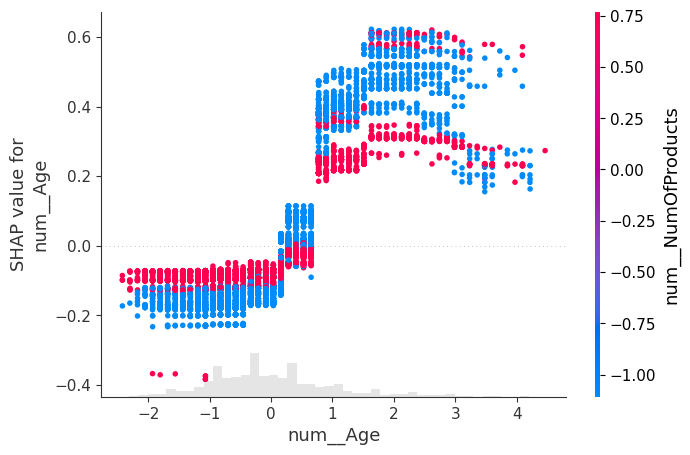

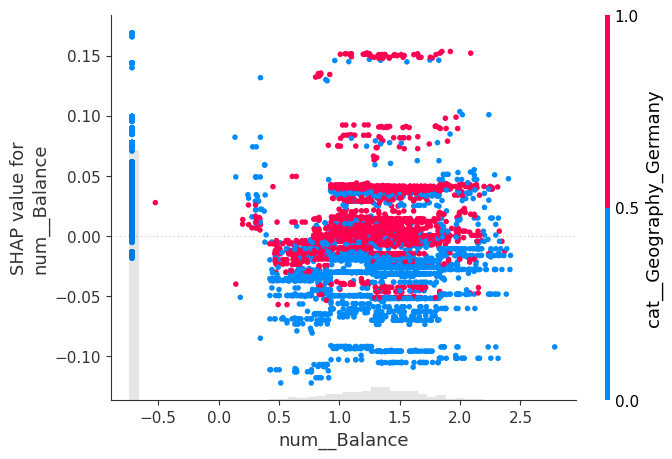

In [144]:
shap.plots.scatter(shap_values_dt[:, "num__Age", 1], color=shap_values_dt[:, :, 1])
shap.plots.scatter(shap_values_dt[:, "num__Balance", 1], color=shap_values_dt[:, "cat__Geography_Germany", 1])

### SHAP Heatmap - Decision Tree

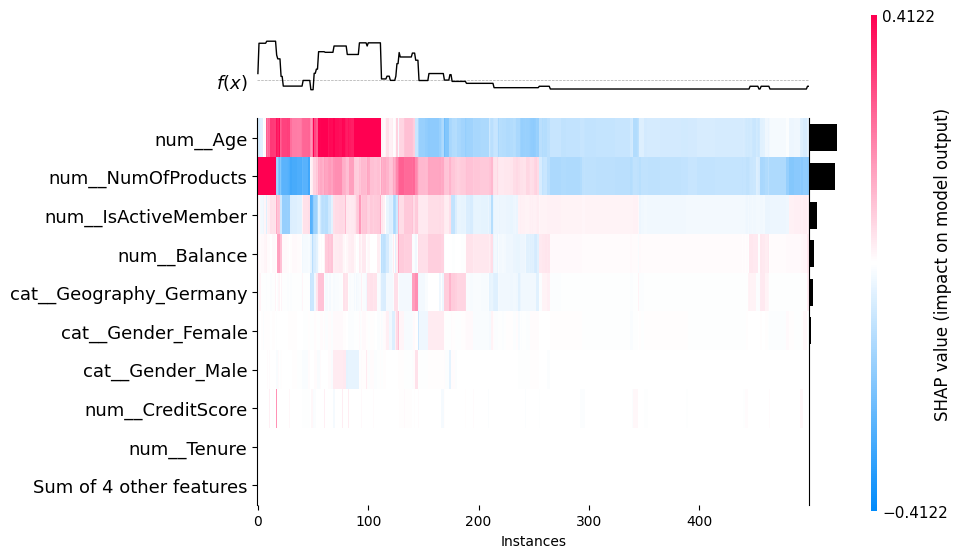

In [148]:
shap.plots.heatmap(shap_values_dt[:500, :, 1]);

## Adaboost

In [160]:
from sklearn.ensemble import AdaBoostClassifier

binary_cat_flag_col_is_spain = {
  'flag_name': 'IsSpain',
    'value': 'Spain',
    'drop_original': True
}

binary_cat_flag_cols_fixed = {
    'Geography': [binary_cat_flag_col_is_germany, binary_cat_flag_col_is_spain]
}

base_estimator = DecisionTreeClassifier(
    max_depth=2,
    min_samples_split=7,
    min_samples_leaf=4,
    random_state=42,
)

result_ada = run_experiment_poly(
    raw_df,
    target_col,
    stratify_col=target_col,
    drop_cols=["Surname", "CustomerId", "Tenure"],
    scale_mode="standard",
    encode_drop="if_binary",
    polynomial_degree=2,
    binary_cat_flag_cols=binary_cat_flag_cols_fixed,
    model=AdaBoostClassifier(
        estimator=base_estimator,
        n_estimators=400,
        learning_rate=0.15,
        random_state=42,
    ),
    num_bin_cols=None
)

lg_roc_auc_train = result_ada["roc_auc_train"]
lg_roc_auc_val = result_ada["roc_auc_val"]
apa_model_pipeline = result_ada["pipeline"]

lg_roc_auc_train, lg_roc_auc_val

(0.9399099921698791, 0.9374864531174978)

In [161]:
# Extract model
model_ada = apa_model_pipeline.named_steps['classifier']
model_ada

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",400
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.15
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [162]:
# Extract transformed X
feature_names_ada = apa_model_pipeline[-2].get_feature_names_out()
X_transformed_ada = apa_model_pipeline[:-1].transform(raw_df)
X_transformed_df_ada = pd.DataFrame(X_transformed_ada, columns=feature_names_ada)
X_transformed_df_ada.head()

,num__CreditScore,num__Age,num__Balance,num__NumOfProducts,num__HasCrCard,num__IsActiveMember,num__EstimatedSalary,num__IsGermany,num__IsSpain,num__CreditScore^2,...,num__IsActiveMember EstimatedSalary,num__IsActiveMember IsGermany,num__IsActiveMember IsSpain,num__EstimatedSalary^2,num__EstimatedSalary IsGermany,num__EstimatedSalary IsSpain,num__IsGermany^2,num__IsGermany IsSpain,num__IsSpain^2,cat__Gender_Male
0,0.264887,-1.067561,-0.717950,2.646802,0.515062,-0.983306,1.373926,-0.467331,-0.530827,0.070165,...,-1.350989,0.459529,0.521965,1.887672,-0.642077,-0.729317,0.218398,0.248072,0.281777,1.0
1,0.389313,-0.453167,-0.717950,0.769304,-1.941514,1.016977,-1.190154,-0.467331,-0.530827,0.151565,...,-1.210359,-0.475265,-0.539839,1.416466,0.556195,0.631766,0.218398,0.248072,0.281777,0.0
2,0.320187,1.758651,-0.717950,2.646802,-1.941514,-0.983306,1.352637,-0.467331,-0.530827,0.102520,...,-1.330056,0.459529,0.521965,1.829628,-0.632129,-0.718017,0.218398,0.248072,0.281777,0.0
3,1.301774,0.775621,0.673394,0.769304,0.515062,-0.983306,0.952344,2.139813,-0.530827,1.694614,...,-0.936446,-2.104091,0.521965,0.906960,2.037839,-0.505530,4.578801,-1.135871,0.281777,1.0
4,-1.587685,2.127288,1.080717,-1.108193,0.515062,-0.983306,1.285185,2.139813,-0.530827,2.520743,...,-1.263730,-2.104091,0.521965,1.651699,2.750055,-0.682211,4.578801,-1.135871,0.281777,0.0


### Feature Importance from model

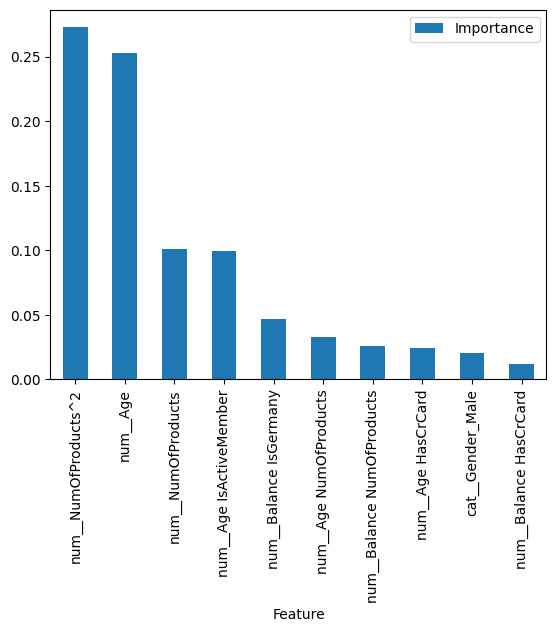

In [188]:
importances = model_ada.feature_importances_
feature_importance_ada_df = pd.DataFrame({'Feature': X_transformed_df_ada.columns, 'Importance': importances})
feature_importance_ada_df = feature_importance_ada_df.sort_values(by='Importance', ascending=False)
feature_importance_ada_df[:10].set_index('Feature').plot.bar();

### SHAP Global plots - Adaboost

In [172]:
%%time
import shap

import warnings
warnings.filterwarnings('ignore')

background = shap.sample(X_transformed_df_ada, 100)

explainer_ada = shap.Explainer(
    model_ada.predict_proba,
    background
)

shap_values_ada = explainer_ada(X_transformed_df_ada[:200])

PermutationExplainer explainer: 201it [02:36,  1.21it/s]                         

CPU times: user 2min 6s, sys: 27.3 s, total: 2min 33s
Wall time: 2min 36s


In [173]:
shap_values_ada_class1 = shap_values_ada[:, :, 1]

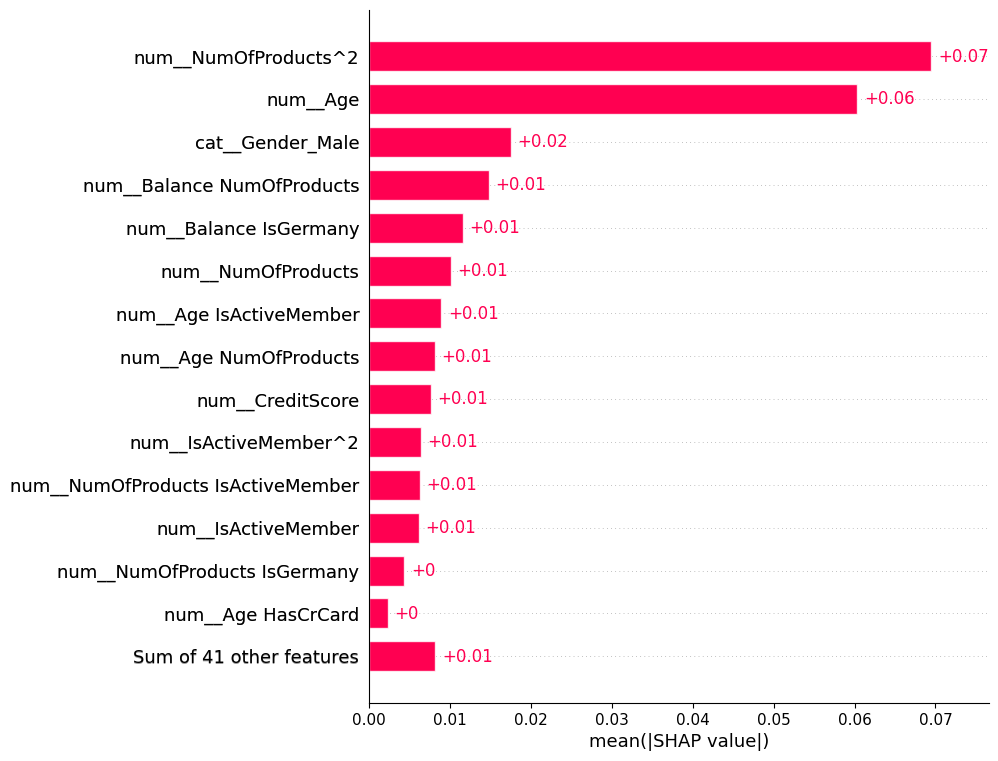

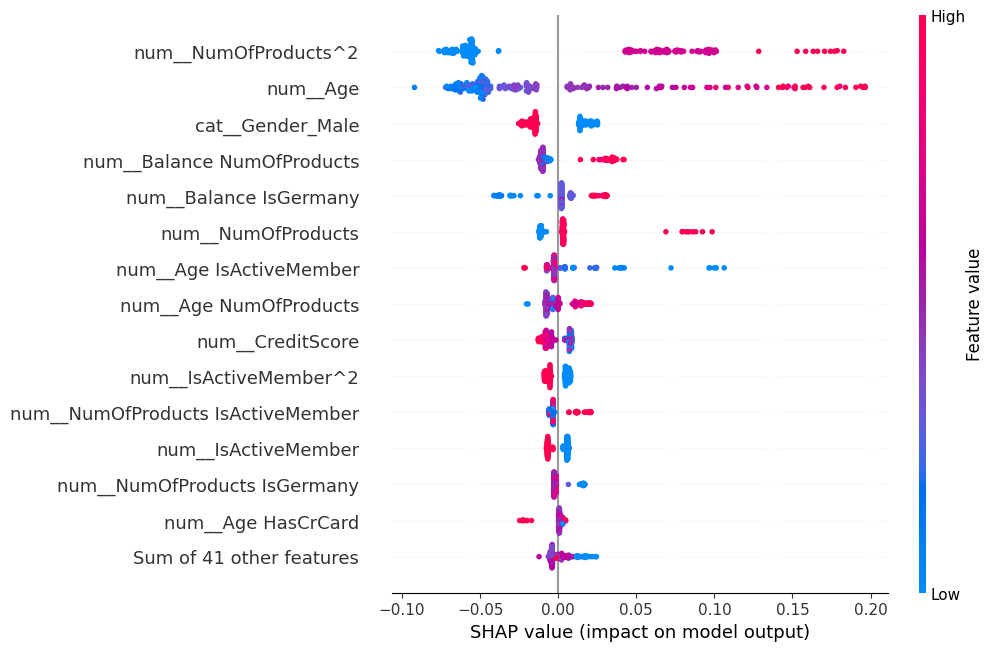

In [177]:
shap.plots.bar(shap_values_ada_class1, max_display=15)
shap.plots.beeswarm(shap_values_ada_class1, max_display=15)

### SHAP Single prediction samples - Adaboost

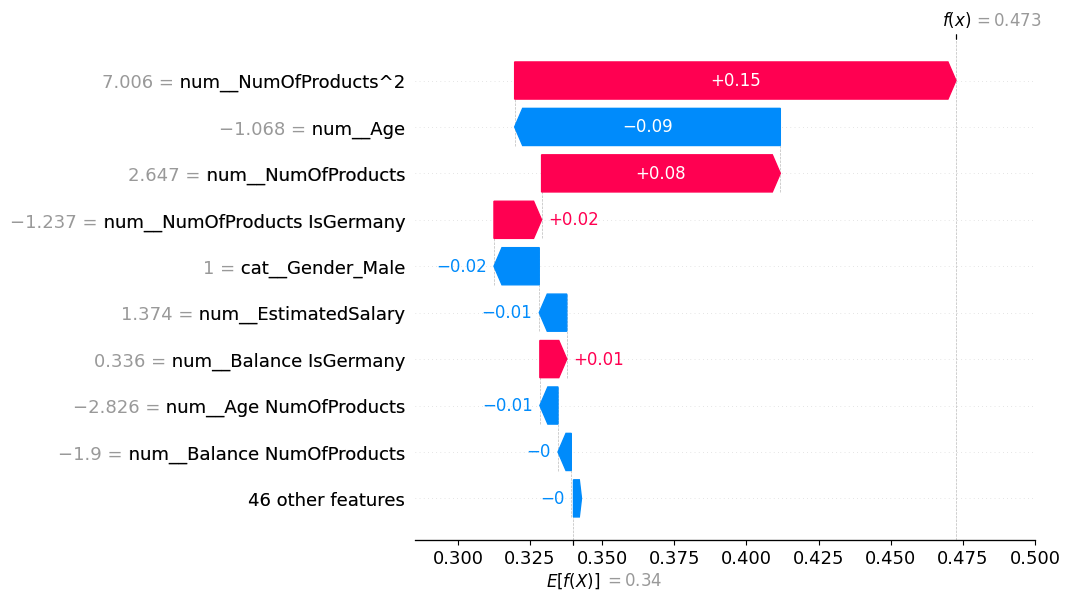

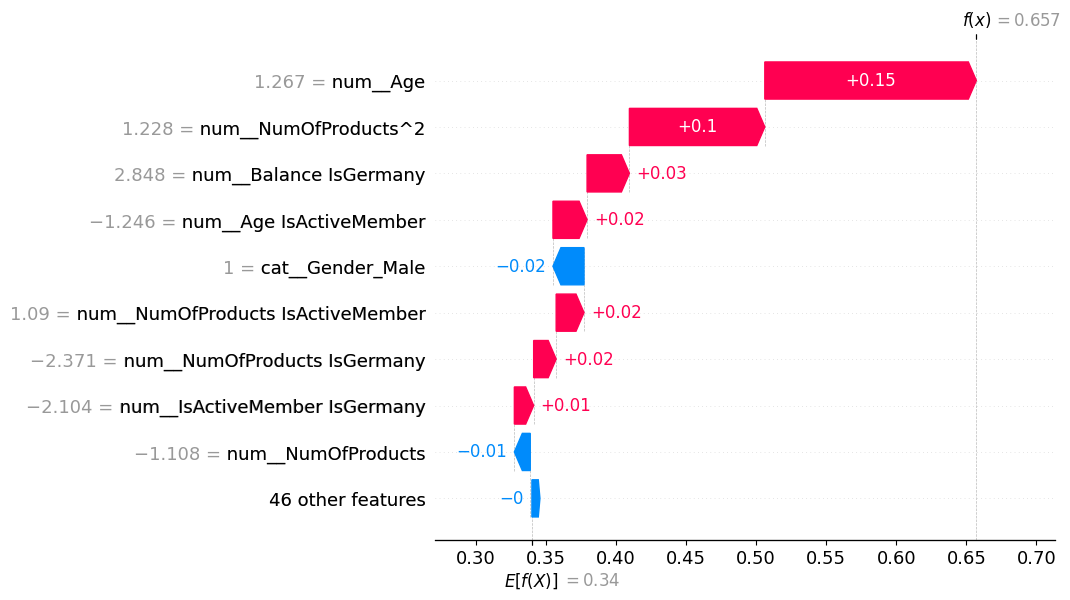

In [178]:
shap.plots.waterfall(shap_values_ada_class1[0])
shap.plots.waterfall(shap_values_ada_class1[100])

### SHAP Dependence plots - Adaboost

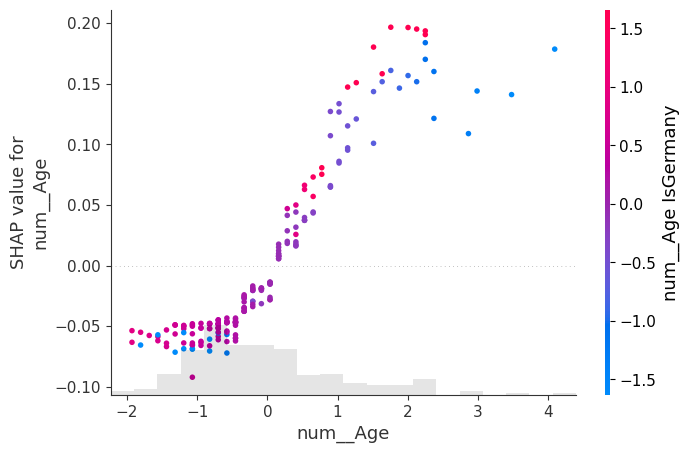

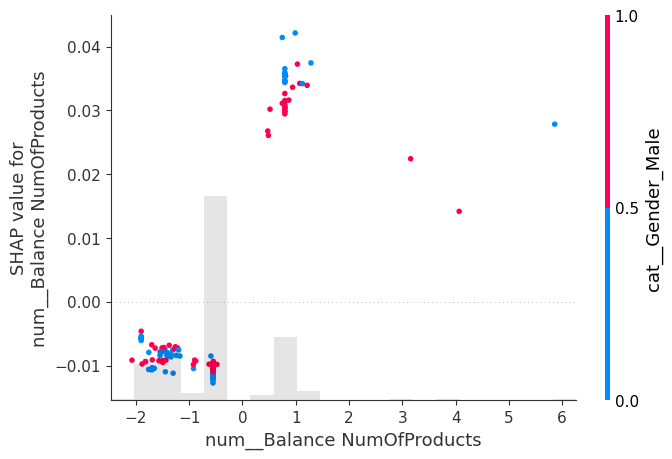

In [180]:
shap.plots.scatter(
    shap_values_ada[:, "num__Age", 1],
    color=shap_values_ada[:, :, 1]
)

shap.plots.scatter(
    shap_values_ada[:, "num__Balance NumOfProducts", 1],
    color=shap_values_ada[:, :, 1]
)

### SHAP Heatmap - Adaboost

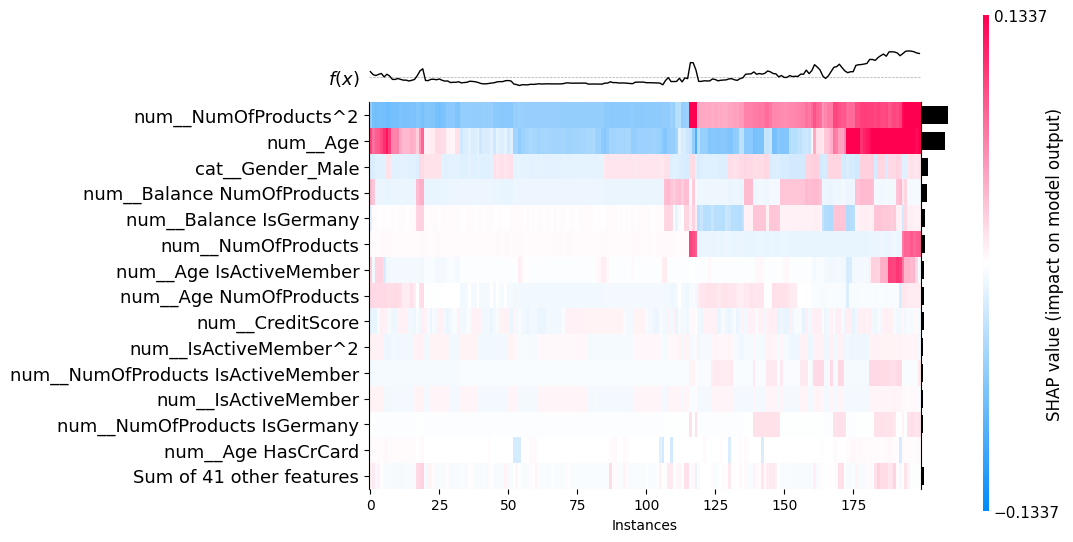

In [182]:
shap.plots.heatmap(shap_values_ada[:500, :, 1], max_display=15);